We will NOT predict individual flight delay.

Instead, we will predict:

Whether a carrier-airport pair will experience HIGH delay rate in a given month.

In [1]:
import pandas as pd
import numpy as np

# Load dataset
file_path = "Airline_Delay_Cause.csv"
df = pd.read_csv(file_path)

# Display first few rows
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [2]:
# Shape of dataset
print("Dataset shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData types:")
print(df.dtypes)


Dataset shape: (171666, 21)

Columns:
Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay'],
      dtype='object')

Data types:
year                     int64
month                    int64
carrier                 object
carrier_name            object
airport                 object
airport_name            object
arr_flights            float64
arr_del15              float64
carrier_ct             float64
weather_ct             float64
nas_ct                 float64
security_ct            float64
late_aircraft_ct       float64
arr_cancelled          float64
arr_diverted           float64
arr_delay              float64
carrier_delay          float64
weather_delay          float64
nas_delay              floa

In [3]:
# Check missing values
null_counts = df.isnull().sum()

print("Missing values per column:")
print(null_counts[null_counts > 0])


Missing values per column:
arr_flights            240
arr_del15              443
carrier_ct             240
weather_ct             240
nas_ct                 240
security_ct            240
late_aircraft_ct       240
arr_cancelled          240
arr_diverted           240
arr_delay              240
carrier_delay          240
weather_delay          240
nas_delay              240
security_delay         240
late_aircraft_delay    240
dtype: int64


In [4]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


In [5]:
df[df["arr_flights"].isnull()].head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
3880,2023,6,MQ,Envoy Air,CLL,"College Station/Bryan, TX: Easterwood Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3894,2023,6,MQ,Envoy Air,EUG,"Eugene, OR: Mahlon Sweet Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3898,2023,6,MQ,Envoy Air,FSD,"Sioux Falls, SD: Joe Foss Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3904,2023,6,MQ,Envoy Air,GRB,"Green Bay, WI: Green Bay Austin Straubel Inter...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3910,2023,6,MQ,Envoy Air,HPN,"White Plains, NY: Westchester County",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df[df["arr_flights"].isnull()].shape

(240, 21)

In [7]:
df = df.dropna(subset=["arr_flights"])

In [8]:
df.isnull().sum()

year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights              0
arr_del15              203
carrier_ct               0
weather_ct               0
nas_ct                   0
security_ct              0
late_aircraft_ct         0
arr_cancelled            0
arr_diverted             0
arr_delay                0
carrier_delay            0
weather_delay            0
nas_delay                0
security_delay           0
late_aircraft_delay      0
dtype: int64

In [9]:
df[df["arr_del15"].isnull()].head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
16907,2022,10,OO,SkyWest Airlines Inc.,PHL,"Philadelphia, PA: Philadelphia International",1.0,NaN,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17282,2022,10,YV,Mesa Airlines Inc.,JAN,"Jackson/Vicksburg, MS: Jackson Medgar Wiley Ev...",1.0,NaN,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27527,2022,4,YV,Mesa Airlines Inc.,MLB,"Melbourne, FL: Melbourne International",1.0,NaN,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27554,2022,4,YV,Mesa Airlines Inc.,SHV,"Shreveport, LA: Shreveport Regional",1.0,NaN,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32066,2022,1,OO,SkyWest Airlines Inc.,BOS,"Boston, MA: Logan International",7.0,NaN,0.0,0.0,...,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
df[df["arr_del15"].isnull()][["arr_flights", "arr_cancelled"]].describe()

,arr_flights,arr_cancelled
count,203.000000,203.000000
mean,9.995074,9.901478
std,17.820751,17.835334
min,1.000000,0.000000
25%,1.000000,1.000000
50%,5.000000,5.000000
75%,10.000000,10.000000
max,120.000000,120.000000


In [11]:
df[df["arr_del15"].isnull()]["arr_flights"].unique()

array([  1.,   7.,   2.,   4., 120.,  28.,  18.,   9.,   8.,   5.,  17.,
        10.,  20.,  13., 112.,  15.,  23.,  11.,  29.,   3.,   6.,  31.,
        12.,  34.,  16.,  21.,  32.,  14.,  19.,  45.,  27.,  71.,  30.,
        94.,  56., 106.,  77.,  22.])

In [12]:
df = df.dropna(subset=["arr_del15"])
df.isnull().sum()

year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64

Rows with undefined arrival delay counts were removed, as they corresponded to months where flights were cancelled and no arrival performance could be evaluated.

In [13]:
df.shape

(171223, 21)

### Target Engineering

In [14]:
df["delay_rate"] = df["arr_del15"] / df["arr_flights"]
df["delay_rate"].describe()

count    171223.000000
mean          0.183365
std           0.110349
min           0.000000
25%           0.109890
50%           0.170732
75%           0.241528
max           1.000000
Name: delay_rate, dtype: float64

<Axes: >

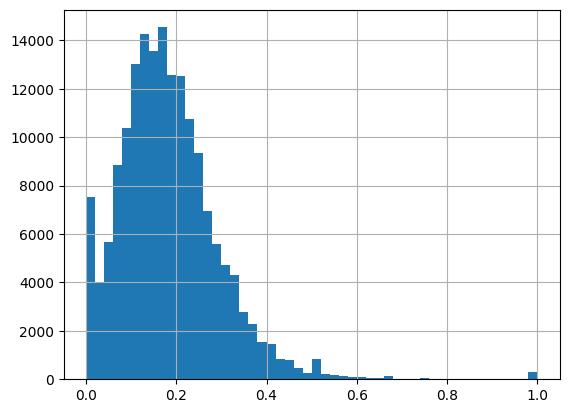

In [15]:
df["delay_rate"].hist(bins=50)

In [16]:
df["delay_rate"].quantile([0.25, 0.5, 0.75])

0.25    0.109890
0.50    0.170732
0.75    0.241528
Name: delay_rate, dtype: float64

In [17]:
df["high_delay"] = (df["delay_rate"] >= 0.25).astype(int)

In [18]:
df["high_delay"].value_counts(normalize=True)

high_delay
0    0.767397
1    0.232603
Name: proportion, dtype: float64

In [19]:
df = df[df["arr_flights"] >= 20]
df.shape
df["delay_rate"].describe()

count    155952.000000
mean          0.183724
std           0.096153
min           0.000000
25%           0.114711
50%           0.172799
75%           0.239766
max           0.903226
Name: delay_rate, dtype: float64

In [20]:
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["log_arr_flights"] = np.log1p(df["arr_flights"])

df["cancel_rate"] = df["arr_cancelled"] / df["arr_flights"]
df["divert_rate"] = df["arr_diverted"] / df["arr_flights"]


In [21]:
print(df.head())
df.shape

   year  month carrier       carrier_name airport  \
0  2023      8      9E  Endeavor Air Inc.     ABE   
1  2023      8      9E  Endeavor Air Inc.     ABY   
2  2023      8      9E  Endeavor Air Inc.     AEX   
3  2023      8      9E  Endeavor Air Inc.     AGS   
4  2023      8      9E  Endeavor Air Inc.     ALB   

                                        airport_name  arr_flights  arr_del15  \
0  Allentown/Bethlehem/Easton, PA: Lehigh Valley ...         89.0       13.0   
1             Albany, GA: Southwest Georgia Regional         62.0       10.0   
2           Alexandria, LA: Alexandria International         62.0       10.0   
3        Augusta, GA: Augusta Regional at Bush Field         66.0       12.0   
4                   Albany, NY: Albany International         92.0       22.0   

   carrier_ct  weather_ct  ...  nas_delay  security_delay  \
0        2.25        1.60  ...      118.0             0.0   
1        1.97        0.04  ...       62.0             0.0   
2        2.73    

(155952, 28)

In [22]:
leakage_cols = [
    "arr_del15",
    "carrier_ct",
    "weather_ct",
    "nas_ct",
    "security_ct",
    "late_aircraft_ct",
    "arr_delay",
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
]

df = df.drop(columns=leakage_cols)


In [23]:
df = df.drop(columns=["carrier_name", "airport_name", "arr_flights", "arr_cancelled", "arr_diverted", "month"])
print(df.head())

   year carrier airport  delay_rate  high_delay  month_sin  month_cos  \
0  2023      9E     ABE    0.146067           0  -0.866025       -0.5   
1  2023      9E     ABY    0.161290           0  -0.866025       -0.5   
2  2023      9E     AEX    0.161290           0  -0.866025       -0.5   
3  2023      9E     AGS    0.181818           0  -0.866025       -0.5   
4  2023      9E     ALB    0.239130           0  -0.866025       -0.5   

   log_arr_flights  cancel_rate  divert_rate  
0         4.499810     0.022472     0.011236  
1         4.143135     0.000000     0.016129  
2         4.143135     0.016129     0.000000  
3         4.204693     0.015152     0.015152  
4         4.532599     0.021739     0.000000  


In [24]:
df = df.drop(columns=["delay_rate"]) ## Target variable is "high_delay", so we drop "delay_rate" to avoid leakage.
df.head()


,year,carrier,airport,high_delay,month_sin,month_cos,log_arr_flights,cancel_rate,divert_rate
0,2023,9E,ABE,0,-0.866025,-0.5,4.499810,0.022472,0.011236
1,2023,9E,ABY,0,-0.866025,-0.5,4.143135,0.000000,0.016129
2,2023,9E,AEX,0,-0.866025,-0.5,4.143135,0.016129,0.000000
3,2023,9E,AGS,0,-0.866025,-0.5,4.204693,0.015152,0.015152
4,2023,9E,ALB,0,-0.866025,-0.5,4.532599,0.021739,0.000000


In [25]:
X = df.drop(columns=["high_delay"])
y = df["high_delay"]

In [26]:
df["year"].unique()

array([2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013])

In [27]:
### Time Based Split
train = df[df["year"] < 2023]
test = df[df["year"] == 2023]

X_train = train.drop(columns=["high_delay"])
y_train = train["high_delay"]

X_test = test.drop(columns=["high_delay"])
y_test = test["high_delay"]


In [28]:
X_train = X_train.drop(columns=["year"])
X_test = X_test.drop(columns=["year"])


### Logistic Regression

In [29]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical_cols = ["carrier", "airport"]
numeric_cols = X_train.drop(columns=categorical_cols).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])


In [30]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.81      0.65      0.72      7184
           1       0.55      0.74      0.63      4104

    accuracy                           0.68     11288
   macro avg       0.68      0.69      0.67     11288
weighted avg       0.72      0.68      0.69     11288

ROC-AUC: 0.7451895551409456


### Random Forest Model

In [32]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


              precision    recall  f1-score   support

           0       0.73      0.90      0.80      7184
           1       0.70      0.42      0.52      4104

    accuracy                           0.72     11288
   macro avg       0.71      0.66      0.66     11288
weighted avg       0.72      0.72      0.70     11288

ROC-AUC: 0.7679059140791535


In [33]:
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

y_pred_adj = (y_prob_rf >= 0.35).astype(int)

print(classification_report(y_test, y_pred_adj))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.78      0.77      0.77      7184
           1       0.61      0.61      0.61      4104

    accuracy                           0.71     11288
   macro avg       0.69      0.69      0.69     11288
weighted avg       0.71      0.71      0.71     11288

ROC-AUC: 0.7679059140791535


Logistic regression achieved higher recall for high-delay months, while Random Forest achieved higher ROC-AUC and precision.
This demonstrates the trade-off between sensitivity and specificity in operational delay prediction.

In [34]:
import pandas as pd

feature_names = (
    numeric_cols.tolist() +
    list(model_rf.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .get_feature_names_out(["carrier", "airport"]))
)

importances = model_rf.named_steps["classifier"].feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp.head(15)


,feature,importance
3,cancel_rate,0.145072
2,log_arr_flights,0.135109
1,month_cos,0.070324
0,month_sin,0.063174
4,divert_rate,0.046491
9,carrier_DL,0.027952
11,carrier_F9,0.013819
8,carrier_B6,0.012033
5,carrier_9E,0.011217
18,carrier_OO,0.007795


🏆 Top Predictors of High Delay
1️⃣ cancel_rate (0.145)

This is the strongest signal.

Interpretation:

Months with higher cancellation rates are strongly associated with high delay rates.

Operational instability clusters together.

This makes real-world sense:

When operations break down, cancellations and delays rise together.

2️⃣ log_arr_flights (0.135)

Airport volume matters a lot.

Interpretation:

Larger airports (higher traffic) are more prone to high delay months.

Congestion effect.

This is a strong operational insight.

3️⃣ Seasonality (month_cos, month_sin)

Combined importance ≈ 0.13

Interpretation:

Time of year significantly affects delays.

Likely winter storms + summer congestion.

This confirms your cyclical encoding was a good decision.

4️⃣ divert_rate (0.046)

Diversions also correlate with high delay.

Again:

Operational stress events cluster.

5️⃣ Carrier Effects

We see:

DL (Delta)

F9 (Frontier)

B6 (JetBlue)

9E (Endeavor)

OO (SkyWest)

WN (Southwest)

These features represent airline-specific behavior.

Important note:
Their individual importance is smaller than operational metrics.

Meaning:

Operational conditions matter more than airline identity.

That’s a powerful insight.

### Model Comparison Visualizations

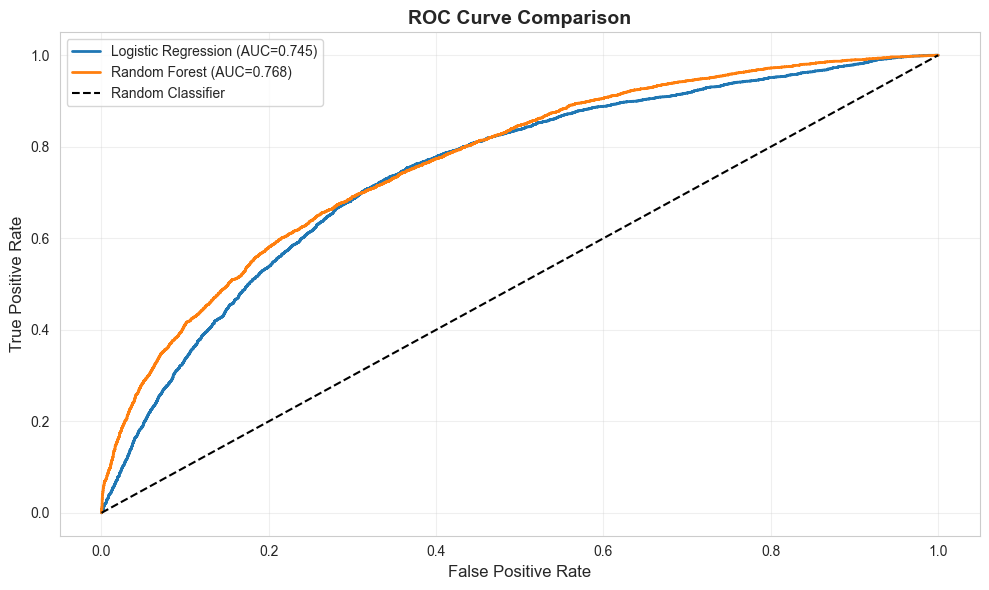

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns

# 1. ROC Curves Comparison
plt.figure(figsize=(10, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.3f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

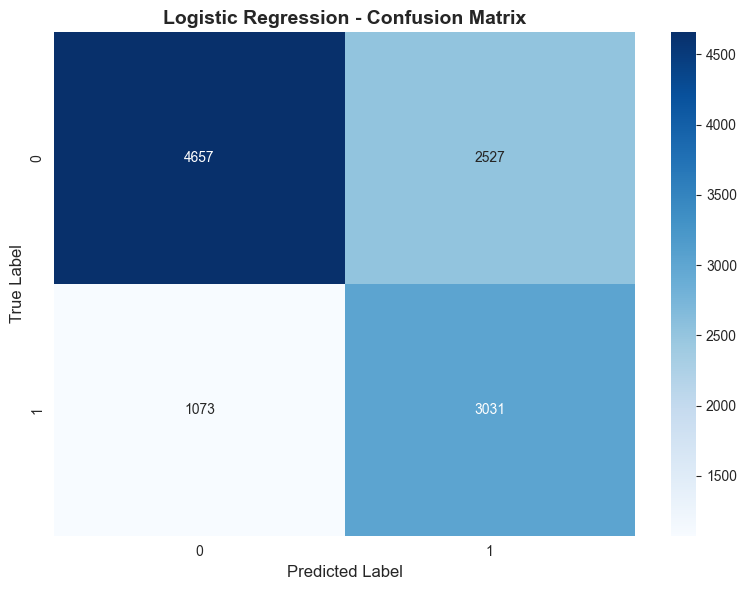

In [37]:
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, model.predict(X_test))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

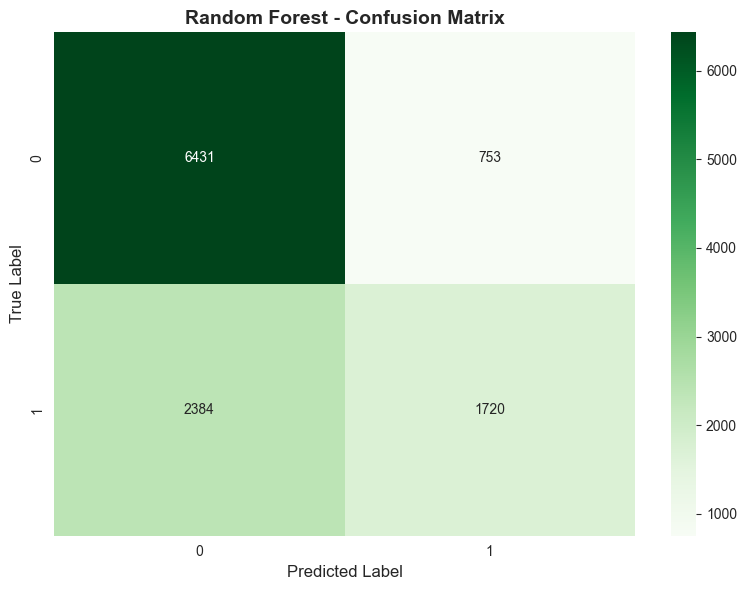

In [38]:
plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=True)
plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

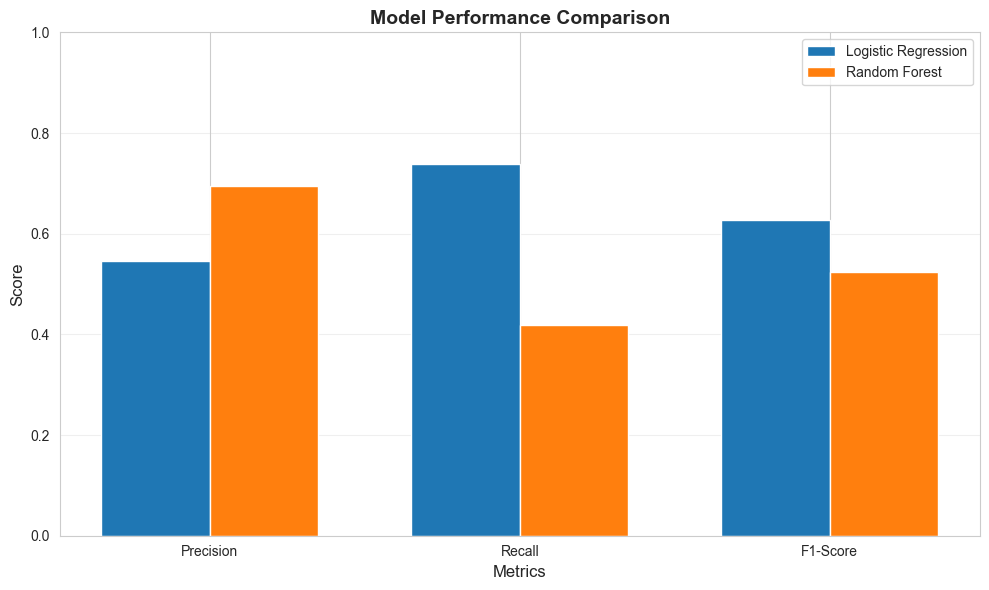

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = ['Precision', 'Recall', 'F1-Score']
lr_scores = [
    precision_score(y_test, model.predict(X_test)),
    recall_score(y_test, model.predict(X_test)),
    f1_score(y_test, model.predict(X_test))
]
rf_scores = [
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, lr_scores, width, label='Logistic Regression')
plt.bar(x + width/2, rf_scores, width, label='Random Forest')
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metrics', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, metrics)
plt.legend(fontsize=10)
plt.ylim([0, 1])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

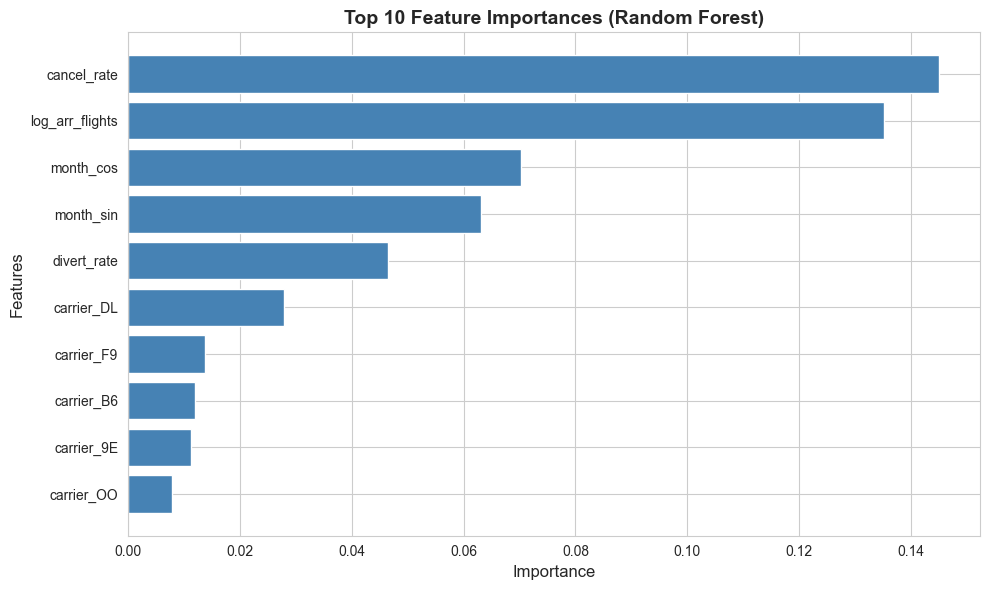

In [40]:
plt.figure(figsize=(10, 6))
feat_imp_top10 = feat_imp.head(10)
plt.barh(feat_imp_top10['feature'], feat_imp_top10['importance'], color='steelblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Top 10 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

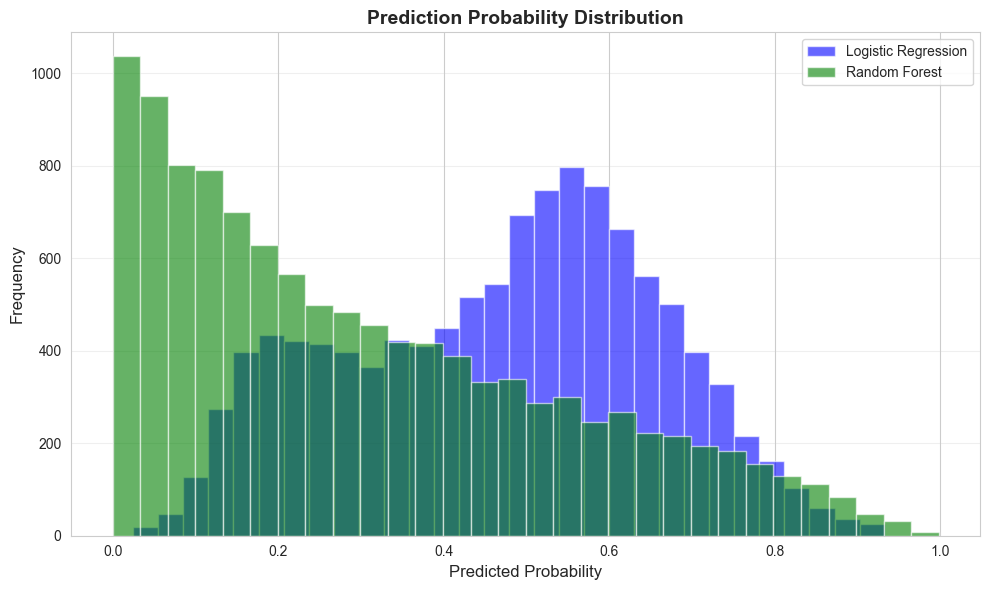

In [41]:
plt.figure(figsize=(10, 6))
plt.hist(model.predict_proba(X_test)[:, 1], bins=30, alpha=0.6, label='Logistic Regression', color='blue')
plt.hist(y_prob_rf, bins=30, alpha=0.6, label='Random Forest', color='green')
plt.xlabel('Predicted Probability', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Prediction Probability Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
df["delay"]

KeyError: 'delay_rate'